In [2]:
import pandas as pd

articles = pd.read_csv('./articles.csv')
customers = pd.read_csv('./customers.csv')
transactions = pd.read_csv('./transactions_train.csv')

In [3]:
articles['text'] = (
    articles['prod_name'] + ' ' +
    articles['product_type_name'] + ' ' +
    articles['colour_group_name'] + ' ' +
    articles['garment_group_name'] + ' ' +
    articles['detail_desc'].fillna('')
)

In [4]:
import numpy as np
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer('all-MiniLM-L6-v2',device='cuda')
all_texts = articles['text'].tolist()
#all_embeddings = st_model.encode(all_texts, show_progress_bar=True, batch_size=256)
#np.save('article_embeddings.npy', all_embeddings)
all_embeddings = np.load('article_embeddings.npy')

c:\Users\swson23\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [5]:
import faiss
dimension = all_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(all_embeddings.astype('float32'))


######여기까지 임베딩 벡터########

In [6]:
query = "casual summer white t-shirt"
query_embedding = st_model.encode([query])

D, I = index.search(query_embedding.astype('float32'), k=10)

# 중복 제거
seen = set()
results = []
for idx in I[0]:
    prod_name = articles.iloc[idx]['prod_name']
    if prod_name not in seen:
        seen.add(prod_name)
        results.append(idx)
    if len(results) == 5:
        break

print("검색 결과 (중복 제거):")
for i, idx in enumerate(results):
    print(f"{i+1}. {articles.iloc[idx]['prod_name']} - {articles.iloc[idx]['detail_desc']}")

검색 결과 (중복 제거):
1. Summer price tee - T-shirt in soft cotton jersey with a print motif.
2. SG Summer Top - Wide-fitting sports top in fast-drying functional fabric with a print motif on the front, cap sleeves and a longer, sewn-in vest top with a racer back.
3. SUMMER Top - Short, wide, sports top in printed, fast-drying mesh layered over a vest top with a racer back.
4. Summer top - Short, wide, sports top in printed, fast-drying mesh layered over a vest top with a racer back.
5. Summer graphic tee - T-shirt in soft jersey with a motif on the front.


In [7]:
# 구매 많은 유저 한 명 뽑기
top_user = transactions['customer_id'].value_counts().index[0]
user_history = transactions[transactions['customer_id'] == top_user]['article_id'].tolist()

In [8]:
# 유저 히스토리 임베딩 평균
article_id_to_idx = {aid: idx for idx, aid in enumerate(articles['article_id'])}

user_embeddings = []
for aid in user_history:
    if aid in article_id_to_idx:
        idx = article_id_to_idx[aid]
        user_embeddings.append(all_embeddings[idx])

user_vector = np.mean(user_embeddings, axis=0, keepdims=True)

# 추천
D, I = index.search(user_vector.astype('float32'), k=10)

seen = set(user_history)
results = []
for idx in I[0]:
    aid = articles.iloc[idx]['article_id']
    if aid not in seen:
        results.append(idx)
    if len(results) == 5:
        break

print("유저 맞춤 추천:")
for i, idx in enumerate(results):
    print(f"{i+1}. {articles.iloc[idx]['prod_name']} - {articles.iloc[idx]['detail_desc']}")
    
    ##############################

유저 맞춤 추천:
1. LASSIE LINEN L/S - Long-sleeved top in soft linen jersey with a V-neck and rounded hem. Longer at the back.
2. Twiggy - Calf-length dress in mesh with a low-cut back and long sleeves. Seam at the waist, a gently flared skirt and raw edges at the cuffs and hem. Jersey lining.
3. LASSIE LINEN L/S - Long-sleeved top in a linen weave with a V-neck. Slightly longer at the back.
4. LASSIE LINEN L/S - Long-sleeved top in soft linen jersey with a V-neck and rounded hem. Longer at the back.
5. LASSIE LINEN L/S - Long-sleeved top in soft linen jersey with a V-neck and rounded hem. Longer at the back.


In [9]:
seen_names = set()
seen_ids = set(user_history)
results = []
for idx in I[0]:
    aid = articles.iloc[idx]['article_id']
    name = articles.iloc[idx]['prod_name']
    if aid not in seen_ids and name not in seen_names:
        seen_names.add(name)
        results.append(idx)
    if len(results) == 5:
        break

print("유저 맞춤 추천 (중복 제거):")
for i, idx in enumerate(results):
    print(f"{i+1}. {articles.iloc[idx]['prod_name']} - {articles.iloc[idx]['detail_desc']}")

유저 맞춤 추천 (중복 제거):
1. LASSIE LINEN L/S - Long-sleeved top in soft linen jersey with a V-neck and rounded hem. Longer at the back.
2. Twiggy - Calf-length dress in mesh with a low-cut back and long sleeves. Seam at the waist, a gently flared skirt and raw edges at the cuffs and hem. Jersey lining.
3. RAVEN halfzip ls - Fitted running top in fast-drying functional fabric with a stand-up collar and zip at the top. Long sleeves with thumbholes at the cuffs, a small zipped pocket at the back, reflective details and a gently rounded hem. Slightly longer at the back. Soft brushed inside.
4. HEATHER halfzip ls - Fitted running top in fast-drying functional fabric with an elasticated hood and a zip at the top. Long raglan sleeves, a small zipped pocket at the back, reflective details and a gently rounded hem. Slightly longer at the back. Soft brushed inside.
5. ELENA baselayer - Base layer tights in a soft wool blend with an elasticated waist.


In [10]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "./qwen"
tokenizer = AutoTokenizer.from_pretrained(model_name)
qwen_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [11]:
def rerank_with_llm(query, candidates, top_k=3):
    candidate_text = "\n".join([
        f"{i+1}. {articles.iloc[idx]['prod_name']}: {articles.iloc[idx]['detail_desc']}"
        for i, idx in enumerate(candidates)
    ])
    
    prompt = f"""당신은 패션 추천 전문가입니다. 반드시 한국어로만 답변하세요. 한자나 중국어는 절대 사용하지 마세요.

사용자 검색어: "{query}"

후보 상품:
{candidate_text}

위 후보 중 가장 적합한 {top_k}개를 선택하고 이유를 설명하세요.
형식:
1. [상품 번호] - [이유]
2. [상품 번호] - [이유]
3. [상품 번호] - [이유]"""

    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(qwen_model.device)
    outputs = qwen_model.generate(**inputs, max_new_tokens=200)
    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return response

In [12]:
query = "나한테 잘 맞는 옷"
query_embedding = st_model.encode([query])
D, I = index.search(query_embedding.astype('float32'), k=10)
result = rerank_with_llm(query, I[0][:5])
print(result)

1. 2 - [Mia l/s top] - 이 옷은 긴 가슴을 자랑하며, 여성스럽고 쾌적한 소재인 토털 섹시 라운드네일과 날카로운 핑크 컬러가 여성미를 더해줍니다. 긴袖는 겨울철에도 활용 가능하며, 기본적인 스타일에 쉽게 매치할 수 있습니다.
2. 3 - [W GARDA SKIRT EQ] - 이 옷은 높은 웨이스트와detachable tie belt가 있어 몸매를 살리는데 효과적이며, 편안하면서도 세련된 디자인이 특징입니다. 티셔츠나 티셔츠 위에 입을 수 있어 다양한 스타일링이 가능합니다.
3. 5 - [Kardashian skirt (


In [13]:
user_vector = np.mean(user_embeddings, axis=0, keepdims=True)

D, I = index.search(user_vector.astype('float32'), k=20)

seen_names = set()
seen_ids = set(user_history)
candidates = []
for idx in I[0]:
    aid = articles.iloc[idx]['article_id']
    name = articles.iloc[idx]['prod_name']
    if aid not in seen_ids and name not in seen_names:
        seen_names.add(name)
        candidates.append(idx)
    if len(candidates) == 5:
        break

result = rerank_with_llm("이 유저의 구매 히스토리 기반 추천", candidates)
print(result)

1. 3 - [Raven halfzip LS] - 이 상품은 사용자의 구매 히스토리에 따라 운동복 히트웨어를 추천하는 것이 적합합니다. 그 이유는 사용자가 이전에 같은 타입의 운동 상품을 구매한 경험이 있기 때문입니다.
2. 4 - [HEATHER halfzip LS] - 이 상품 역시 운동복과 관련된 제품으로, 사용자의 구매 패턴을 고려할 때 적합합니다. 특히 이 상품은 에어링 디테일과 립업 캡슐이 있어 더욱 세부적인 추천 요소가 될 수 있습니다.
3. 1 - [LASSIE LINEN L/S] - 마지막으로, 이 상품은 셔츠와 같은 페미닌한 스타일의 제품으로, 여성 고객의 구


In [14]:

from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model
import torch
from datasets import load_dataset
dataset = load_dataset("beomi/KoAlpaca-v1.1a")
def format_data(item):
    return {"text": f"### 지시사항:\n{item['instruction']}\n\n### 답변:\n{item['output']}"}

train_dataset = dataset['train'].map(format_data, remove_columns=['instruction', 'output', 'url'])

tokenizer = AutoTokenizer.from_pretrained("./qwen")
tokenizer.pad_token = tokenizer.eos_token

# 토크나이징
def tokenize(item):
    result = tokenizer(
        item["text"],
        truncation=True,
        max_length=512,
        padding="max_length"
    )
    result["labels"] = result["input_ids"].copy()
    return result

tokenized_dataset = train_dataset.map(tokenize, remove_columns=["text"])
print(tokenized_dataset)

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 21155
})


In [15]:
import torch
from peft import LoraConfig, get_peft_model

qwen_model = AutoModelForCausalLM.from_pretrained(
    "./qwen",
    torch_dtype=torch.float16,
    device_map="cuda"
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

#qwen_model = get_peft_model(qwen_model, lora_config)
#qwen_model.config.use_cache = False
#qwen_model.print_trainable_parameters()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [16]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

training_args = TrainingArguments(
    output_dir="./qwen_korean",
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=100,
    save_steps=500,
    warmup_steps=100,
    report_to="none",
    save_safetensors=False
)

trainer = Trainer(
    model=qwen_model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False)
)

#trainer.train()

In [17]:
#qwen_model.save_pretrained("./qwen_korean")
#tokenizer.save_pretrained("./qwen_korean")

In [18]:
# 1. 모델 로드
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

tokenizer = AutoTokenizer.from_pretrained("./qwen")
base_model = AutoModelForCausalLM.from_pretrained(
    "./qwen",
    torch_dtype=torch.float16,
    device_map="cuda"
)
korean_model = PeftModel.from_pretrained(base_model, "./qwen_korean")
#korean_model.eval()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [19]:
del qwen_model
del base_model
torch.cuda.empty_cache()

In [20]:
def rerank_with_llm(query, candidates, top_k=3):
    candidate_text = "\n".join([
        f"{i+1}. 상품명: {articles.iloc[idx]['prod_name']}, 카테고리: {articles.iloc[idx]['product_type_name']}, 색상: {articles.iloc[idx]['colour_group_name']}, 설명: {articles.iloc[idx]['detail_desc'][:80]}"
        for i, idx in enumerate(candidates)
    ])
    
    prompt = f"""당신은 패션 추천 전문가입니다. 반드시 한국어로만 답변하세요. 한자나 중국어는 절대 사용하지 마세요.

사용자 검색어: "{query}"

후보 상품:
{candidate_text}

위 후보 중 가장 적합한 {top_k}개를 선택하고 이유를 설명하세요.
형식:
[상품 번호] - [이유]
"""

    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(korean_model.device)
    outputs = korean_model.generate(**inputs, max_new_tokens=500)
    response = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return response


In [21]:
query = "나한테 잘 맞는 옷"
query_embedding = st_model.encode([query])
D, I = index.search(query_embedding.astype('float32'), k=10)
result = rerank_with_llm(query, I[0][:5])
print(result)

1. [상품명: W GARDA SKIRT EQ, 색상: Beige] - 높은 밸런스와 시원함을 느낄 수 있는 beige 색상의 스커트입니다. 허리가 높아지고, 부드러운 니트와 함께 착용하기 좋습니다.
2. [상품명: W GARDA SKIRT EQ, 색상: Pink] - 이전과 동일한 이유로 선택합니다. 다양한 스타일에 어울리는 색상으로, 여성스럽고 매력적인 이미지를 줍니다.
3. [상품명: Singapore, 색상: Dark Grey] - 디테일이 과한 것이 아닌 단순하면서도 우아한 디자인으로, 다양한 스타일에 어울릴 것입니다. 흰색이나 다른 색상과 함께 착용하기 좋은 편안한 느낌을 줍니다.

이 외에도, 사용자의 키, 몸매, 스타일에 따라 다른 스커트들이 더 적합할 수 있습니다. 하지만 이 세 가지는 대부분의 경우에 적합한 스커트입니다.


In [ ]:
##################################################

In [ ]:
print(f"VRAM 사용량: {torch.cuda.memory_allocated()/1024**3:.2f}GB")
print(f"VRAM 남은 양: {torch.cuda.memory_reserved()/1024**3:.2f}GB")

In [ ]:

####메인 임베딩

import sys
sys.path.append("./Qwen3-VL-Embedding-2B")

import os
import torch
import chromadb
import pandas as pd
from scripts.qwen3_vl_embedding import Qwen3VLEmbedder

# 모델 로딩
model = Qwen3VLEmbedder(
    model_name_or_path="./Qwen3-VL-Embedding-2B",
    torch_dtype=torch.bfloat16,
    max_pixels=256*256,
)
print("모델 로딩 완료")

INSTRUCTION = "Retrieve fashion items relevant to the query."

# ChromaDB 세팅
client = chromadb.PersistentClient(path="./chroma_db")

try:
    client.delete_collection("fashion_items")
    print("기존 collection 삭제")
except:
    pass

collection = client.create_collection(
    name="fashion_items",
    metadata={"hnsw:space": "cosine"}
)

# 이미지 경로 생성
def get_image_path(article_id):
    folder = str(article_id)[:3]
    return f"./images/{folder}/{article_id}.jpg"

def print_vram():
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved  = torch.cuda.memory_reserved() / 1024**3
    print(f"VRAM | 사용중: {allocated:.2f}GB | 예약됨: {reserved:.2f}GB")

# 인덱싱
articles = pd.read_csv('./articles.csv', dtype={'article_id': str})
#articles = articles.head(100)
print(f"전체 아이템 수: {len(articles)}")
batch_size = 4

total_with_image = 0
total_without_image = 0

for i in range(0, len(articles), batch_size):
    batch = articles.iloc[i:i+batch_size]

    inputs = []
    for _, row in batch.iterrows():
        text = (
            f"{row['prod_name']} {row['product_type_name']} "
            f"{row['colour_group_name']} "
            f"{row['detail_desc'] if pd.notna(row['detail_desc']) else ''}"
        )
        img_path = get_image_path(row['article_id'])
        inp = {"text": text, "instruction": INSTRUCTION}
        if os.path.exists(img_path):
            inp["image"] = img_path
            total_with_image += 1
        else:
            total_without_image += 1
        inputs.append(inp)

    embeddings = model.process(inputs)

    collection.add(
        embeddings=embeddings.tolist(),
        documents=[inp["text"] for inp in inputs],
        metadatas=[{
            "article_id": str(row['article_id']),
            "prod_name": row['prod_name'],
            "has_image": os.path.exists(get_image_path(row['article_id']))
        } for _, row in batch.iterrows()],
        ids=[str(row['article_id']) for _, row in batch.iterrows()]
    )

    if i % 10 == 0:
        print(f"{i}/{len(articles)} 완료 | 이미지 있음: {total_with_image} | 없음: {total_without_image}")
        print_vram()

print(f"\n저장된 아이템 수: {collection.count()}")
print(f"이미지 있음: {total_with_image} | 없음: {total_without_image}")
print_vram()

# 검색
def search(query: str, n_results: int = 10):
    query_emb = model.process([{
        "text": query,
        "instruction": INSTRUCTION
    }])

    results = collection.query(
        query_embeddings=query_emb.tolist(),
        n_results=n_results
    )

    docs      = results['documents'][0]
    metadatas = results['metadatas'][0]
    distances = results['distances'][0]

    print(f"\n검색어: '{query}'\n{'─'*50}")
    for rank, (doc, meta, dist) in enumerate(
        zip(docs, metadatas, distances), 1
    ):
        sim = 1 - dist
        print(f"{rank:2}. [sim={sim:.3f}] {meta['prod_name']} {'🖼' if meta['has_image'] else '📝'}")
        print(f"      {doc[:80]}{'...' if len(doc) > 80 else ''}")
    return results

search("dress")
search("blue jacket")

c:\Users\swson23\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
`torch_dtype` is deprecated! Use `dtype` instead!


모델 로딩 완료
기존 collection 삭제
전체 아이템 수: 105542
0/105542 완료 | 이미지 있음: 4 | 없음: 0
VRAM | 사용중: 3.97GB | 예약됨: 4.04GB
20/105542 완료 | 이미지 있음: 24 | 없음: 0
VRAM | 사용중: 3.97GB | 예약됨: 4.04GB
40/105542 완료 | 이미지 있음: 44 | 없음: 0
VRAM | 사용중: 3.97GB | 예약됨: 4.04GB
60/105542 완료 | 이미지 있음: 64 | 없음: 0
VRAM | 사용중: 3.97GB | 예약됨: 4.04GB
80/105542 완료 | 이미지 있음: 84 | 없음: 0
VRAM | 사용중: 3.97GB | 예약됨: 4.04GB
100/105542 완료 | 이미지 있음: 103 | 없음: 1
VRAM | 사용중: 3.97GB | 예약됨: 4.04GB
120/105542 완료 | 이미지 있음: 122 | 없음: 2
VRAM | 사용중: 3.97GB | 예약됨: 4.04GB
140/105542 완료 | 이미지 있음: 142 | 없음: 2
VRAM | 사용중: 3.97GB | 예약됨: 4.04GB
160/105542 완료 | 이미지 있음: 162 | 없음: 2
VRAM | 사용중: 3.97GB | 예약됨: 4.04GB
180/105542 완료 | 이미지 있음: 182 | 없음: 2
VRAM | 사용중: 3.97GB | 예약됨: 4.04GB
200/105542 완료 | 이미지 있음: 202 | 없음: 2
VRAM | 사용중: 3.97GB | 예약됨: 4.04GB
220/105542 완료 | 이미지 있음: 222 | 없음: 2
VRAM | 사용중: 3.97GB | 예약됨: 4.04GB
240/105542 완료 | 이미지 있음: 242 | 없음: 2
VRAM | 사용중: 3.97GB | 예약됨: 4.04GB
260/105542 완료 | 이미지 있음: 259 | 없음: 5
VRAM | 사용중: 3.97GB | 예약됨: 4.04GB
280

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def search(query: str = None, image_path: str = None, n_results: int = 10):
    inp = {"instruction": INSTRUCTION}
    if query:
        inp["text"] = query
    if image_path:
        inp["image"] = image_path

    query_emb = model.process([inp])

    results = collection.query(
        query_embeddings=query_emb.tolist(),
        n_results=n_results
    )

    docs      = results['documents'][0]
    metadatas = results['metadatas'][0]
    distances = results['distances'][0]

    title = f"{query or ''} {image_path or ''}".strip()
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(f"검색: '{title}'", fontsize=16)
    axes = axes.flatten()

    print(f"\n검색: '{title}'\n{'─'*50}")
    for rank, (doc, meta, dist) in enumerate(zip(docs, metadatas, distances), 1):
        sim = 1 - dist
        print(f"{rank:2}. [sim={sim:.3f}] {meta['prod_name']} {'[IMG]' if meta['has_image'] else '[TXT]'}")
        print(f"      {doc[:80]}{'...' if len(doc) > 80 else ''}")

        ax = axes[rank-1]
        img_path = get_image_path(meta['article_id'])
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'No Image', ha='center', va='center')
        ax.set_title(f"{rank}. {meta['prod_name'][:20]}\nsim={sim:.3f}", fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    return results

# 텍스트만
search("dress")
search("blue jacket")

# 이미지만
search(image_path=get_image_path(articles.iloc[0]['article_id']))

# 텍스트+이미지
search("blue jacket", image_path=get_image_path(articles.iloc[0]['article_id']))

NameError: name 'INSTRUCTION' is not defined

`torch_dtype` is deprecated! Use `dtype` instead!


모델 로딩 완료
컬렉션 로딩 완료: 1000개

검색: 'dress'
──────────────────────────────────────────────────
 1. [sim=0.519] Lena Rib Dress (1) [TXT]
      Lena Rib Dress (1) Dress Black Fitted, sleeveless dress in ribbed jersey.
 2. [sim=0.492] Alcazar strap dress [TXT]
      Alcazar strap dress Dress Black Long, sleeveless dress in jersey with narrow sho...
 3. [sim=0.452] Alcazar strap dress [IMG]
      Alcazar strap dress Dress Dark Green Long, sleeveless dress in jersey with narro...
 4. [sim=0.438] Alcazar strap dress [IMG]
      Alcazar strap dress Dress Dark Pink Long, sleeveless dress in jersey with narrow...
 5. [sim=0.435] Hilton [IMG]
      Hilton Dress Other Strapless jersey dress with an elasticated waist. Inner top w...
 6. [sim=0.434] Dress LS Basic [IMG]
      Dress LS Basic Dress Red Long-sleeved dress in soft, patterned organic cotton je...
 7. [sim=0.433] Basic SS dress [IMG]
      Basic SS dress Dress Dark Blue Short-sleeved dress in soft organic cotton jersey...
 8. [sim=0.430] Basi

C:\Users\swson23\AppData\Local\Temp\ipykernel_37148\1220783689.py:74: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\swson23\AppData\Local\Temp\ipykernel_37148\1220783689.py:74: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\swson23\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\swson23\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


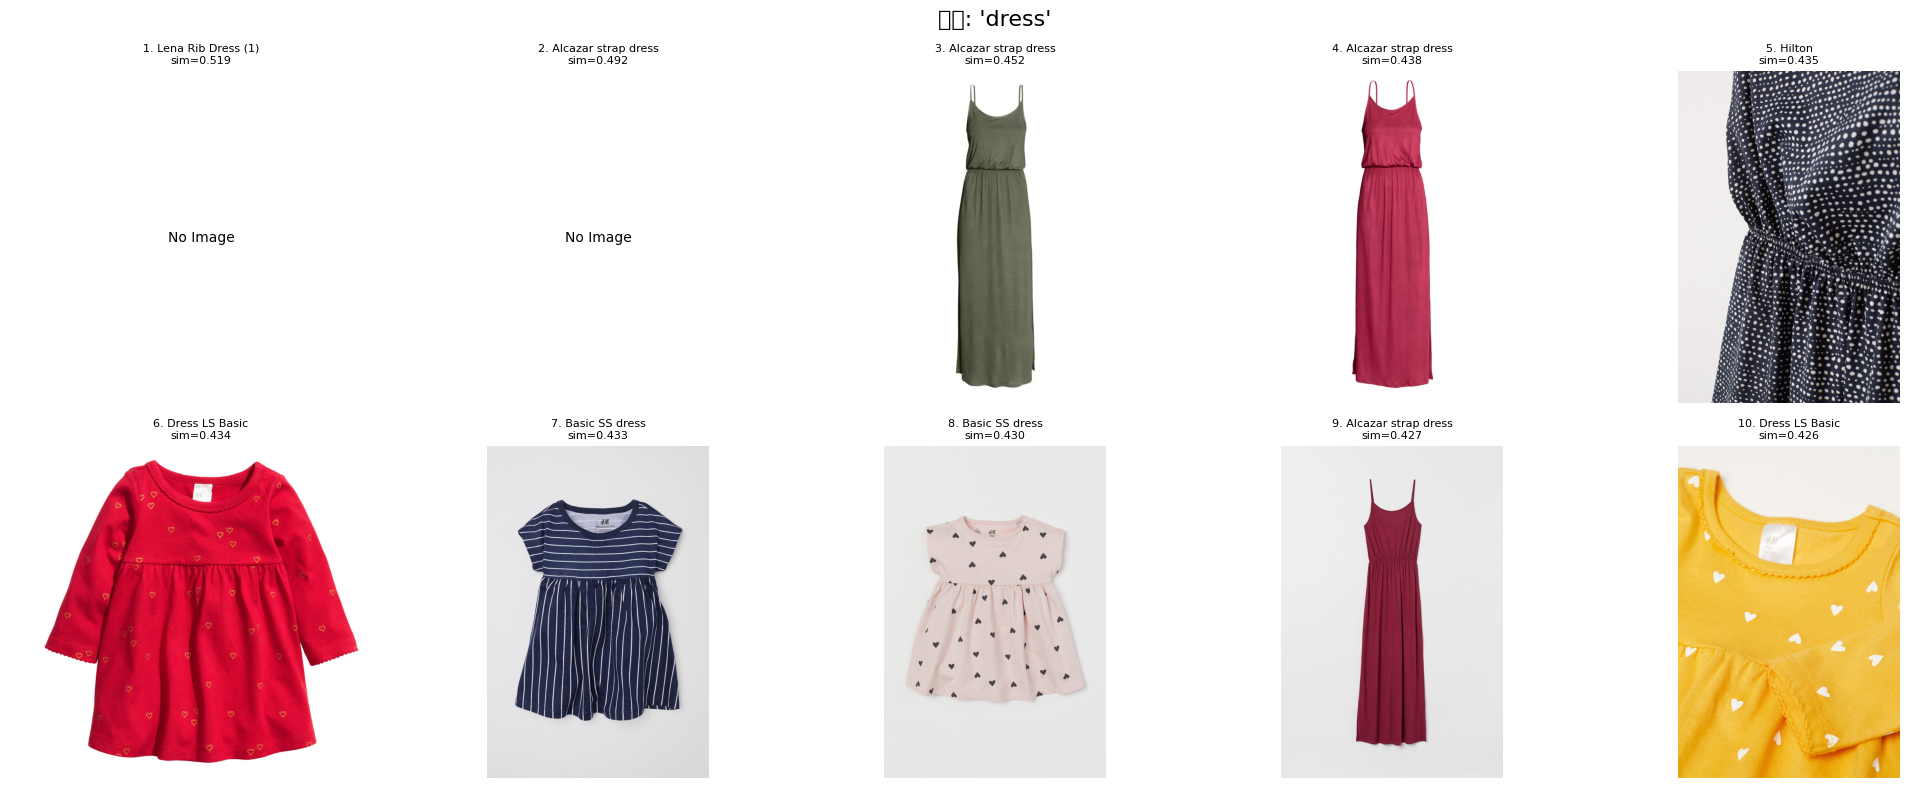


검색: 'blue jacket'
──────────────────────────────────────────────────
 1. [sim=0.440] Theron (1) [IMG]
      Theron (1) Hoodie Dark Blue Jacket in sweatshirt fabric with a lined drawstring ...
 2. [sim=0.420] Janet SL (W) [IMG]
      Janet SL (W) Pyjama set Blue Pyjamas in a soft cotton weave. Long-sleeved shirt ...
 3. [sim=0.407] Manson SF slim fit blazer [IMG]
      Manson SF slim fit blazer Blazer Dark Blue Single-breasted jacket in woven fabri...
 4. [sim=0.394] Manson SF slim fit blazer [IMG]
      Manson SF slim fit blazer Blazer Dark Blue Single-breasted jacket in woven fabri...
 5. [sim=0.391] FLEECE PYJAMA [IMG]
      FLEECE PYJAMA Pyjama jumpsuit/playsuit Dark Blue All-in-one pyjamas in soft, pat...
 6. [sim=0.389] Janet SL-set (W) [IMG]
      Janet SL-set (W) Pyjama set Dark Blue Pyjamas in a soft cotton weave. Long-sleev...
 7. [sim=0.389] Manson SF slim fit blazer [IMG]
      Manson SF slim fit blazer Blazer Dark Blue Single-breasted jacket in woven fabri...
 8. [sim=0.38

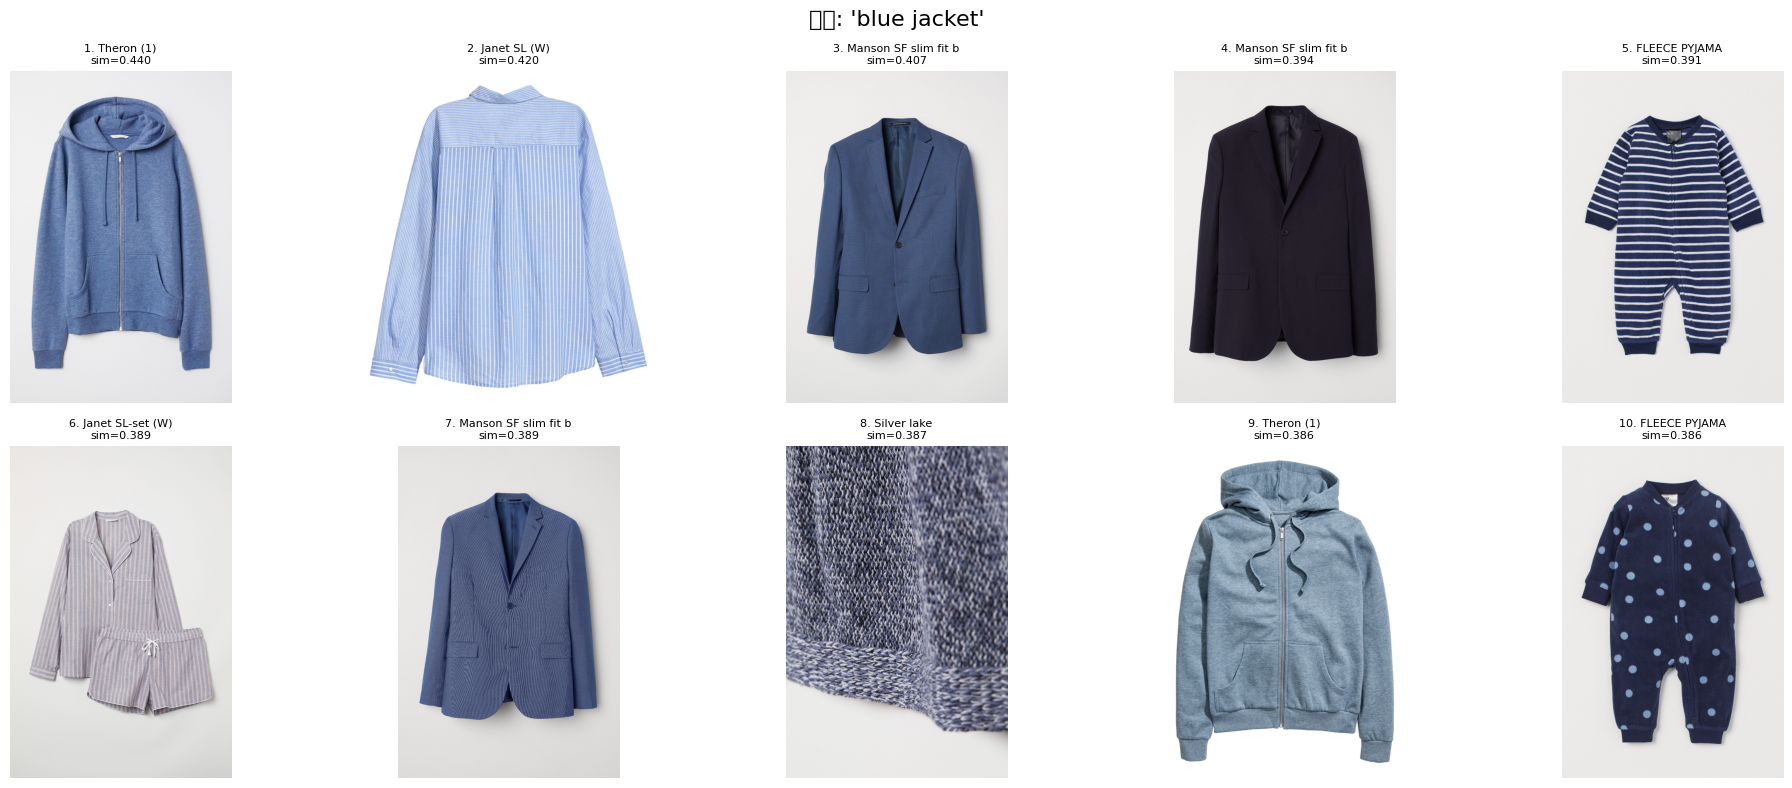


검색: './images/010/0108775015.jpg'
──────────────────────────────────────────────────
 1. [sim=0.724] Strap top [IMG]
      Strap top Vest top Black Jersey top with narrow shoulder straps.
 2. [sim=0.598] HELENA 2-pack tanktop [IMG]
      HELENA 2-pack tanktop Vest top Black Tops in soft organic cotton jersey.
 3. [sim=0.588] Strap top [IMG]
      Strap top Vest top White Jersey top with narrow shoulder straps.
 4. [sim=0.566] Hilton [IMG]
      Hilton Dress Black Strapless jersey dress with an elasticated waist. Inner top w...
 5. [sim=0.545] TORKEL tanktop SB 2-p [IMG]
      TORKEL tanktop SB 2-p Vest top Black Vest tops in soft, ribbed organic cotton je...
 6. [sim=0.544] OP Strapless^ [IMG]
      OP Strapless^ Bra Black Strapless bra in microfibre with underwired, padded cups...
 7. [sim=0.511] HELENA 2-pack tanktop [IMG]
      HELENA 2-pack tanktop Vest top Turquoise Tops in soft organic cotton jersey.
 8. [sim=0.506] Strap top (1) [IMG]
      Strap top (1) Vest top Off White Jers

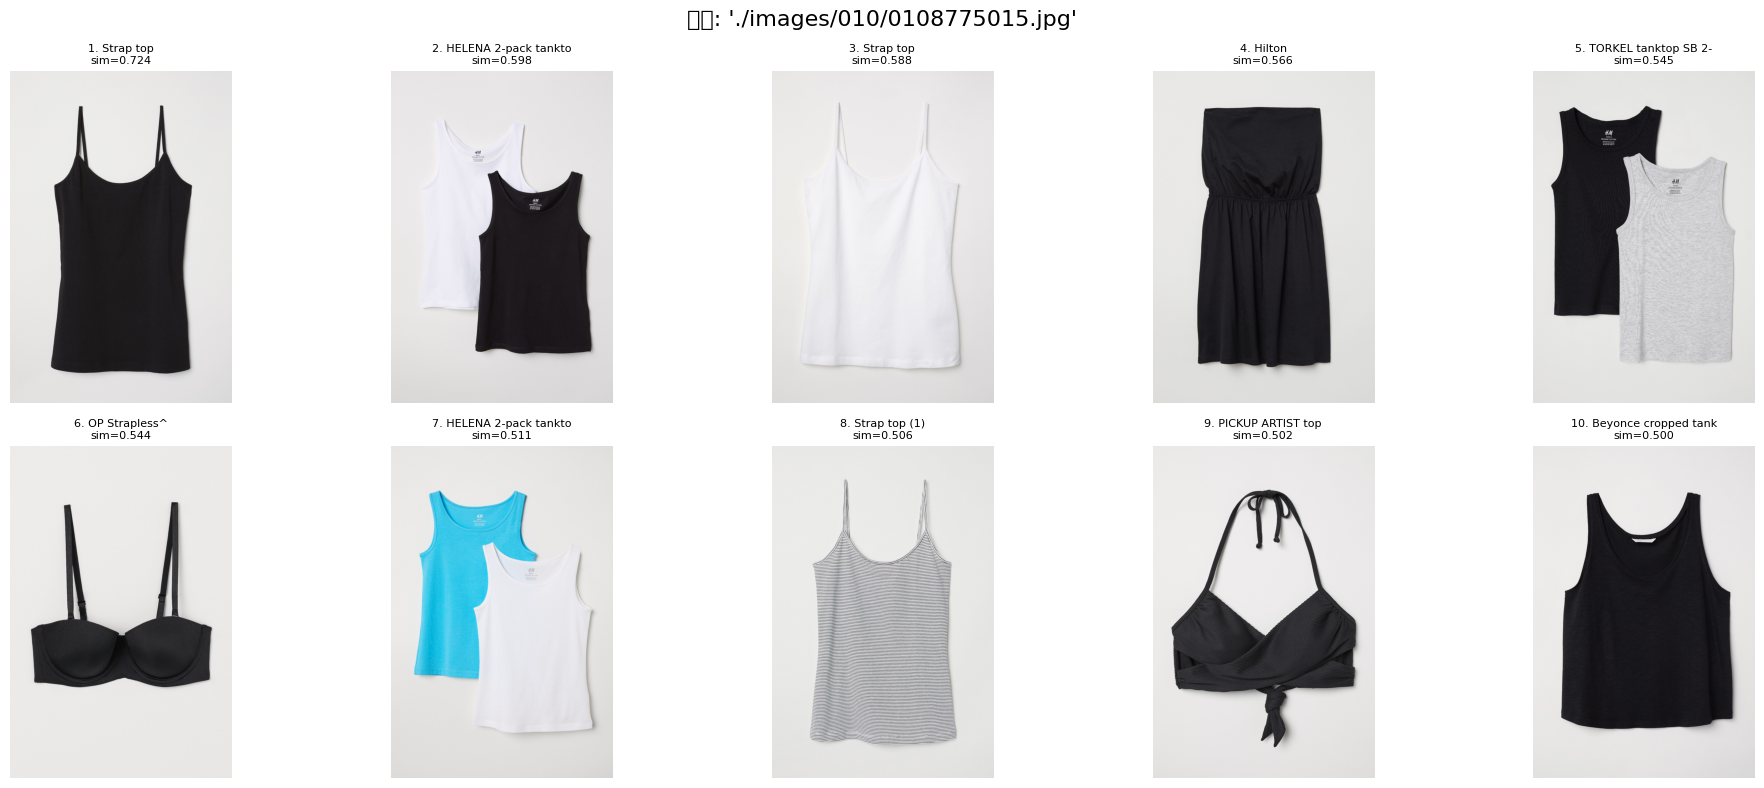


검색: 'blue jacket ./images/010/0108775015.jpg'
──────────────────────────────────────────────────
 1. [sim=0.557] Strap top [IMG]
      Strap top Vest top Black Jersey top with narrow shoulder straps.
 2. [sim=0.470] HELENA 2-pack tanktop [IMG]
      HELENA 2-pack tanktop Vest top Turquoise Tops in soft organic cotton jersey.
 3. [sim=0.463] Strap top [IMG]
      Strap top Vest top White Jersey top with narrow shoulder straps.
 4. [sim=0.453] Lima l/s [IMG]
      Lima l/s Top Dark Blue Long-sleeved fitted top in jersey.
 5. [sim=0.445] HELENA 2-pack tanktop [IMG]
      HELENA 2-pack tanktop Vest top Black Tops in soft organic cotton jersey.
 6. [sim=0.443] Hilton [IMG]
      Hilton Dress Dark Blue Strapless jersey dress with an elasticated waist. Inner t...
 7. [sim=0.437] Frugan longsleeve [IMG]
      Frugan longsleeve Top Dark Blue Fitted top in soft stretch jersey with a wide ne...
 8. [sim=0.431] Hilton [IMG]
      Hilton Dress Black Strapless jersey dress with an elasticated waist

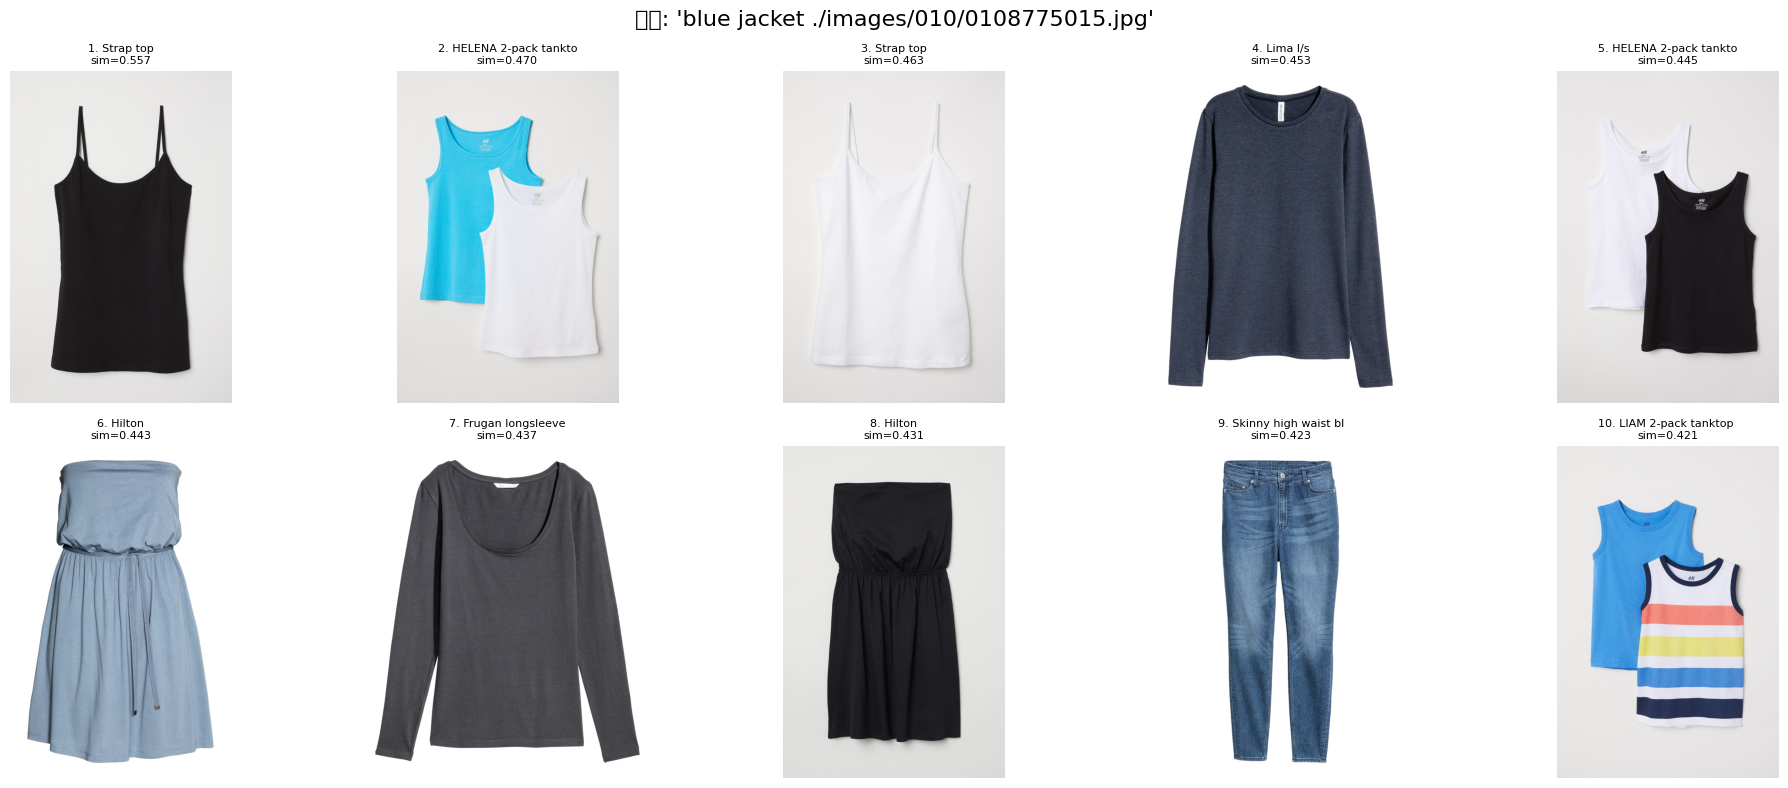

{'ids': [['0108775015',
   '0194270046',
   '0108775044',
   '0238197030',
   '0194270002',
   '0299733007',
   '0116379047',
   '0299733001',
   '0297898002',
   '0268450036']],
 'embeddings': None,
 'documents': [['Strap top Vest top Black Jersey top with narrow shoulder straps.',
   'HELENA 2-pack tanktop Vest top Turquoise Tops in soft organic cotton jersey.',
   'Strap top Vest top White Jersey top with narrow shoulder straps.',
   'Lima l/s Top Dark Blue Long-sleeved fitted top in jersey.',
   'HELENA 2-pack tanktop Vest top Black Tops in soft organic cotton jersey.',
   'Hilton Dress Dark Blue Strapless jersey dress with an elasticated waist. Inner top with elastication at the top.',
   'Frugan longsleeve Top Dark Blue Fitted top in soft stretch jersey with a wide neckline and long sleeves.',
   'Hilton Dress Black Strapless jersey dress with an elasticated waist. Inner top with elastication at the top.',
   'Skinny high waist black Trousers Blue 5-pocket jeans in dyed, superstr

In [7]:
import sys
sys.path.append("./Qwen3-VL-Embedding-2B")

import os
import torch
import chromadb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scripts.qwen3_vl_embedding import Qwen3VLEmbedder

# 모델 로딩
model = Qwen3VLEmbedder(
    model_name_or_path="./Qwen3-VL-Embedding-2B",
    torch_dtype=torch.bfloat16,
    max_pixels=256*256,
)
print("모델 로딩 완료")

INSTRUCTION = "Retrieve fashion items relevant to the query."

# ChromaDB 세팅 (기존 컬렉션 불러오기)
client = chromadb.PersistentClient(path="./chroma_db")
collection = client.get_collection("fashion_items")
print(f"컬렉션 로딩 완료: {collection.count()}개")

articles = pd.read_csv('./articles.csv', dtype={'article_id': str})

# 이미지 경로 생성
def get_image_path(article_id):
    folder = str(article_id)[:3]
    return f"./images/{folder}/{article_id}.jpg"

# 검색
def search(query: str = None, image_path: str = None, n_results: int = 10):
    inp = {"instruction": INSTRUCTION}
    if query:
        inp["text"] = query
    if image_path:
        inp["image"] = image_path

    query_emb = model.process([inp])

    results = collection.query(
        query_embeddings=query_emb.tolist(),
        n_results=n_results
    )

    docs      = results['documents'][0]
    metadatas = results['metadatas'][0]
    distances = results['distances'][0]

    title = f"{query or ''} {image_path or ''}".strip()
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(f"검색: '{title}'", fontsize=16)
    axes = axes.flatten()

    print(f"\n검색: '{title}'\n{'─'*50}")
    for rank, (doc, meta, dist) in enumerate(zip(docs, metadatas, distances), 1):
        sim = 1 - dist
        print(f"{rank:2}. [sim={sim:.3f}] {meta['prod_name']} {'[IMG]' if meta['has_image'] else '[TXT]'}")
        print(f"      {doc[:80]}{'...' if len(doc) > 80 else ''}")

        ax = axes[rank-1]
        img_path = get_image_path(meta['article_id'])
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'No Image', ha='center', va='center')
        ax.set_title(f"{rank}. {meta['prod_name'][:20]}\nsim={sim:.3f}", fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    return results

# 텍스트만
search("dress")
search("blue jacket")

# 이미지만
search(image_path=get_image_path(articles.iloc[0]['article_id']))

# 텍스트+이미지
search("blue jacket", image_path=get_image_path(articles.iloc[0]['article_id']))

In [ ]:
import sys
sys.path.append("./Qwen3-VL-Embedding-2B")
import gc
import os
import torch
import chromadb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scripts.qwen3_vl_embedding import Qwen3VLEmbedder
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

INSTRUCTION = "Retrieve fashion items relevant to the query."

client = chromadb.PersistentClient(path="./chroma_db")
collection = client.get_collection("fashion_items")
print(f"컬렉션 로딩 완료: {collection.count()}개")

articles = pd.read_csv('./articles.csv', dtype={'article_id': str})

def print_vram():
    allocated = torch.cuda.memory_allocated() / 1024**3
    print(f"VRAM 사용: {allocated:.2f}GB")

def get_image_path(article_id):
    folder = str(article_id)[:3]
    return f"./images/{folder}/{article_id}.jpg"

def search_and_recommend(query: str = None, image_path: str = None, n_results: int = 10):
    # 1. 임베딩 모델 올리고 검색
    embedding_model = Qwen3VLEmbedder(
        model_name_or_path="./Qwen3-VL-Embedding-2B",
        torch_dtype=torch.bfloat16,
        max_pixels=256*256,
    )
    print("임베딩 모델 로딩 완료")
    print_vram()

    inp = {"instruction": INSTRUCTION}
    if query:
        inp["text"] = query
    if image_path:
        inp["image"] = image_path

    query_emb = embedding_model.process([inp])
    results = collection.query(
        query_embeddings=query_emb.tolist(),
        n_results=n_results
    )

    del embedding_model
    gc.collect()
    torch.cuda.empty_cache()
    print("임베딩 모델 내림")
    print_vram()

    docs      = results['documents'][0]
    metadatas = results['metadatas'][0]
    distances = results['distances'][0]

    # 2. 검색 결과 시각화
    title = f"{query or ''} {image_path or ''}".strip()
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(f"검색: '{title}'", fontsize=16)
    axes = axes.flatten()

    print(f"\n검색: '{title}'\n{'─'*50}")
    for rank, (doc, meta, dist) in enumerate(zip(docs, metadatas, distances), 1):
        sim = 1 - dist
        print(f"{rank:2}. [sim={sim:.3f}] {meta['prod_name']} {'[IMG]' if meta['has_image'] else '[TXT]'}")
        print(f"      {doc[:80]}{'...' if len(doc) > 80 else ''}")

        ax = axes[rank-1]
        img_path = get_image_path(meta['article_id'])
        if os.path.exists(img_path):
            img = mpimg.imread(img_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'No Image', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{rank}. {meta['prod_name'][:20]}\nsim={sim:.3f}", fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    # 3. Instruct 모델 올리고 reranking
    instruct_model = Qwen3VLForConditionalGeneration.from_pretrained(
        "./Qwen3-VL-2B-Instruct",
        torch_dtype=torch.bfloat16,
        device_map="cuda"
    )
    instruct_processor = AutoProcessor.from_pretrained("./Qwen3-VL-2B-Instruct")
    print("Instruct 모델 로딩 완료")
    print_vram()

    content = []
    if image_path and os.path.exists(image_path):
        content.append({"type": "image", "image": image_path})
        content.append({"type": "text", "text": "위 이미지는 사용자가 입력한 참고 이미지입니다.\n"})

    for i, meta in enumerate(metadatas, 1):
        img_path = get_image_path(meta['article_id'])
        if os.path.exists(img_path):
            content.append({"type": "image", "image": img_path})
        content.append({"type": "text", "text": f"[{i}] {meta['prod_name']}\n"})

    prompt = f"검색어: '{query or '이미지 검색'}'\n\n위 검색 결과 {n_results}개 중 가장 적합한 아이템 3개를 추천하고 한국어로 이유를 설명해주세요."
    content.append({"type": "text", "text": prompt})

    messages = [{"role": "user", "content": content}]

    inputs = instruct_processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    ).to("cuda")

    with torch.no_grad():
        output = instruct_model.generate(**inputs, max_new_tokens=512)

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, output)
    ]
    response = instruct_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    del instruct_model, instruct_processor
    gc.collect()
    torch.cuda.empty_cache()
    print("Instruct 모델 내림")
    print_vram()

    print(f"\n🤖 LLM 추천:\n{response}")
    return results, response


# 텍스트만
search_and_recommend("dress")

# 이미지만
search_and_recommend(image_path=get_image_path(articles.iloc[0]['article_id']))

# 텍스트+이미지
search_and_recommend("blue jacket", image_path=get_image_path(articles.iloc[0]['article_id']))

In [ ]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
import torch
import time

def print_vram():
    allocated = torch.cuda.memory_allocated() / 1024**3
    print(f"VRAM 사용: {allocated:.2f}GB")

instruct_model = Qwen3VLForConditionalGeneration.from_pretrained(
    "./Qwen3-VL-2B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="cuda"
)
instruct_processor = AutoProcessor.from_pretrained(
    "./Qwen3-VL-2B-Instruct",
    max_pixels=256*256
)
print("로딩 완료")
print_vram()

sample_image = "./images/010/0108775015.jpg"  # 실제 있는 이미지 경로로 바꿔요

def run_test(name, messages):
    inputs = instruct_processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    ).to("cuda")

    token_count = inputs.input_ids.shape[1]

    start = time.time()
    with torch.no_grad():
        output = instruct_model.generate(**inputs, max_new_tokens=256, repetition_penalty=1.5)
    elapsed = time.time() - start

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, output)
    ]
    response = instruct_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    print(f"\n{'='*50}")
    print(f"[{name}]")
    print(f"입력 토큰 수: {token_count}")
    print(f"소요 시간: {elapsed:.1f}초")
    print(f"응답: {response[:200]}")
    print_vram()

# 1. 텍스트만
run_test("텍스트만", [
    {"role": "user", "content": [
        {"type": "text", "text": "파란 재킷 추천해줘"}
    ]}
])

# 2. 이미지만
run_test("이미지만", [
    {"role": "user", "content": [
        {"type": "image", "image": sample_image},
        {"type": "text", "text": "이 옷을 설명해줘"}
    ]}
])

# 3. 이미지 + 텍스트
run_test("이미지 + 텍스트", [
    {"role": "user", "content": [
        {"type": "image", "image": sample_image},
        {"type": "text", "text": "이 옷이 파란 재킷이랑 잘 어울려?"}
    ]}
])

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

로딩 완료
VRAM 사용: 3.97GB

[텍스트만]
입력 토큰 수: 16
소요 시간: 61.2초
응답: 아주 좋은 질문이에요! 파랑색의재킷을 선택할 때는 옷감, 기능성(예: 겨울용), 스타일 등 여러 요소를 고려해야 해서 그림자 없게 잘 맞춤하는 것이 중요합니다. 아래에서 다양한 상황과 취향별로 **추가적인 팁**도 함께 드릴 수 있어요!

---

### ✅ 1️⃣ 🎯 어떤 경우엔 '정말' 따뜻한 파란재킷?
- ❌ 일반적 "기분 좋고 예쁜" 라면 → 보통은
VRAM 사용: 3.97GB

[이미지만]
입력 토큰 수: 71
소요 시간: 76.9초
응답: 물론입니다. 이 이미지에는 검은색 슬림한 디자인의 베스트 티셔츠가 보여요.

- **형식**: 반팔 셀프 탑 또는 스트레칭 치마로, 라운드 넥과 얇고 짧게 설계된 가슴 부분(아랫배)에 따라 담백하고 깨끗하게 느껴집니다.
  
  - 전체적인 형태는 단순하면서도 세련되며,
    천연 석회석처럼 부드러워서 감촉감 있는 느낌으로 외출이나 일상에서 착용하기 좋습
VRAM 사용: 3.97GB

[이미지 + 텍스트]
입력 토큰 수: 79
소요 시간: 80.1초
응답: 아니요, 이 이미지에는 **파란색**의 가방이나 다른 의류가 보입니다.  
하지만 질문에서 언급된 '재킷'은 실제 사진에 존재하는 것처럼 들리기 때문에 그 의미를 확실하게 판단해야 합니다.

---

### 분석:

1.  👕 *제품*: 검정 색상 스트레칭 베스트 또는 릴렉스 스타일 티셔츠.
2.  🌈 *배경/조명*:
    - 배치는 매우 단순하고 밝습니
VRAM 사용: 3.97GB


In [1]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
import torch
import time

def print_vram():
    allocated = torch.cuda.memory_allocated() / 1024**3
    print(f"VRAM 사용: {allocated:.2f}GB")

from transformers import BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(load_in_4bit=True)
instruct_model = Qwen3VLForConditionalGeneration.from_pretrained(
    "./Qwen3-VL-2B-Instruct",
    quantization_config=bnb_config,
    device_map="cuda"
)
instruct_processor = AutoProcessor.from_pretrained(
    "./Qwen3-VL-2B-Instruct",
    max_pixels=256*256
)
print("로딩 완료")
print_vram()

sample_image = "./images/010/0108775015.jpg"  # 실제 있는 이미지 경로로 바꿔요

def run_test(name, messages):
    inputs = instruct_processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    ).to("cuda")

    token_count = inputs.input_ids.shape[1]

    start = time.time()
    with torch.no_grad():
        output = instruct_model.generate(**inputs, max_new_tokens=256, repetition_penalty=1.5)
    elapsed = time.time() - start

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, output)
    ]
    response = instruct_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    print(f"\n{'='*50}")
    print(f"[{name}]")
    print(f"입력 토큰 수: {token_count}")
    print(f"소요 시간: {elapsed:.1f}초")
    print(f"응답: {response[:200]}")
    print_vram()

# 1. 텍스트만
run_test("텍스트만", [
    {"role": "user", "content": [
        {"type": "text", "text": "파란 재킷 추천해줘"}
    ]}
])

# 2. 이미지만
run_test("이미지만", [
    {"role": "user", "content": [
        {"type": "image", "image": sample_image},
        {"type": "text", "text": "이 옷을 설명해줘"}
    ]}
])

# 3. 이미지 + 텍스트
run_test("이미지 + 텍스트", [
    {"role": "user", "content": [
        {"type": "image", "image": sample_image},
        {"type": "text", "text": "이 옷이 파란 재킷이랑 잘 어울려?"}
    ]}
])

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

로딩 완료
VRAM 사용: 1.55GB

[텍스트만]
입력 토큰 수: 16
소요 시간: 12.6초
응답: 물론! 파 blue(보라색)의 향기 있는 계절을 위한 **매력적인 블루 코트**를 선택하기 위해 다양한 스타일과 분위기를 살려서, 아래에 20개 이상으로 정리하여 소개드릴게요. (제품명은 실제 상점에서 확인 가능하게 하며 실제로는 "블러코츠"라고 합니다.)

---

### ✅ 핫한 패션 튜브:  
1️⹁ Blue Wool Coat - A437968-5L

VRAM 사용: 1.56GB

[이미지만]
입력 토큰 수: 71
소요 시간: 13.8초
응답: 아무리 이 이미지가 흐름에 뚜렷하게 보이는 것이라도, 그 위의 내용은 전부 정확히 기록되어야 합니다. 따라서 다음과 같이 해석해야 할 수 있습니다.

하지만 실제로는 해당 오브젝트를 바라보며 분명한 구조와 의미로 판단할 필요성이 있으며,

그러면 아래에서 다시 조사하는 것이 좋습니다:

- "어떤 상품인지"
  - 예: 코스프레 제품

"여기서 '오직'이라
VRAM 사용: 1.56GB

[이미지 + 텍스트]
입력 토큰 수: 79
소요 시간: 13.5초
응답: 아주 아름답게, 이 이미지에 있는 검은색 스트링 티셔츠는 매우 세련된 느낌을 주고 있으며, 그 자체로도 매력적인 스타일의 상품입니다. 그러나 '파인'과 같은 라벨이나 제품명으로 표현되는 것은 없으며 "재단"이라는 의미를 가질 수 있음.

그러면 원문에서 제시한 질문: “이 옵니가 파른 코스팅이라고 하며”라는 문장에는 오류와 다소 불확실함(예) 있습니다?


VRAM 사용: 1.56GB


In [ ]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
import torch
import time

def print_vram():
    allocated = torch.cuda.memory_allocated() / 1024**3
    print(f"VRAM 사용: {allocated:.2f}GB")

bnb_config = BitsAndBytesConfig(load_in_8bit=True)
instruct_model = Qwen3VLForConditionalGeneration.from_pretrained(
    "./Qwen3-VL-2B-Instruct",
    quantization_config=bnb_config,
    device_map="cuda"
)
instruct_processor = AutoProcessor.from_pretrained(
    "./Qwen3-VL-2B-Instruct",
    max_pixels=256*256
)
print("로딩 완료")
print_vram()

sample_image = "./images/010/0108775015.jpg"

def run_test(name, messages):
    inputs = instruct_processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    ).to("cuda")

    token_count = inputs.input_ids.shape[1]

    start = time.time()
    with torch.no_grad():
        output = instruct_model.generate(**inputs, max_new_tokens=256, repetition_penalty=1.5)
    elapsed = time.time() - start

    generated_ids_trimmed = [
        out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, output)
    ]
    response = instruct_processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    print(f"\n{'='*50}")
    print(f"[{name}]")
    print(f"입력 토큰 수: {token_count}")
    print(f"소요 시간: {elapsed:.1f}초")
    print(f"응답: {response[:200]}")
    print_vram()

# 1. 텍스트만
run_test("텍스트만", [
    {"role": "user", "content": [
        {"type": "text", "text": "파란 재킷 추천해줘"}
    ]}
])

# 2. 이미지만
run_test("이미지만", [
    {"role": "user", "content": [
        {"type": "image", "image": sample_image},
        {"type": "text", "text": "이 옷을 설명해줘"}
    ]}
])

# 3. 이미지 + 텍스트
run_test("이미지 + 텍스트", [
    {"role": "user", "content": [
        {"type": "image", "image": sample_image},
        {"type": "text", "text": "이 옷이 파란 재킷이랑 잘 어울려?"}
    ]}
])

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]